# Comparing two sets of SVCode files

Two analyses each wrote one CSV per dive. Every row is one grid cell: a time, a
depth, the 18 and 38 kHz Sv in that cell, and a code.

This notebook lines the two sets up cell by cell and asks one question: **how
many dB apart are they?**

A cell is compared only when both files have a row with the same time and the
same depth. Differences are always **mine minus reference**, so a positive number
means my Sv is higher.

## 1. Where the files are

Edit these two folders. Each should hold the per-dive files, named like `SWD_20160707-OE20.csv`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REFERENCE_DIR = Path("../../../NEFSC_UC1/full_data/Auxiliary/Sv_codes")
MINE_DIR = Path("../../../NEFSC_UC1/Clustering_results/results/outputs_MVBS_Seabed/sv_codes")

## 2. Match the cells

For each dive found in both folders, keep the cells that appear in both files.

In [ ]:
KEYS = ["DateTime", "depth_m"]

matched = []
for reference_file in sorted(REFERENCE_DIR.glob("SWD_*.csv")):
    my_file = MINE_DIR / reference_file.name
    if not my_file.exists():
        print("skipped, not in my folder:", reference_file.name)
        continue
    reference = pd.read_csv(reference_file)
    mine = pd.read_csv(my_file)
    both = reference.merge(mine, on=KEYS, suffixes=("_ref", "_mine"))
    both["dive"] = reference_file.stem
    matched.append(both)
    print(f"{reference_file.stem}: reference {len(reference)} cells, mine {len(mine)}, matched {len(both)}")

cells = pd.concat(matched, ignore_index=True)

# mine minus reference, in dB
cells["diff_18"] = cells["18kHz_Sv_mine"] - cells["18kHz_Sv_ref"]
cells["diff_38"] = cells["38kHz_Sv_mine"] - cells["38kHz_Sv_ref"]

# the 18 minus 38 kHz gap is what separates one kind of scatterer from another
cells["gap_ref"] = cells["18kHz_Sv_ref"] - cells["38kHz_Sv_ref"]
cells["gap_mine"] = cells["18kHz_Sv_mine"] - cells["38kHz_Sv_mine"]
cells["diff_gap"] = cells["gap_mine"] - cells["gap_ref"]

print()
print("matched cells in total:", len(cells))

SWD_20160707-OE20: reference 2270 cells, mine 2273, matched 2188
SWD_20160707-OE29: reference 2102 cells, mine 2093, matched 2049
SWD_20160707-OE32: reference 2059 cells, mine 2024, matched 1923
SWD_20160719-OE07: reference 1500 cells, mine 1507, matched 1445
SWD_20160725-OE50: reference 1935 cells, mine 1935, matched 1877
SWD_20160725-OE54: reference 2853 cells, mine 2744, matched 2422
SWD_20160725-OE61: reference 1743 cells, mine 1740, matched 1569
SWD_20160725-OE62: reference 4377 cells, mine 4303, matched 4120
SWD_20160725-OE64: reference 4046 cells, mine 3900, matched 3637
SWD_20160802-OE16: reference 1548 cells, mine 1542, matched 1460
SWD_20160814-OE03: reference 2704 cells, mine 2673, matched 2563
SWD_20160814-OE09: reference 3616 cells, mine 3185, matched 2923
SWD_20160814-OE44: reference 2094 cells, mine 2102, matched 1942

matched cells in total: 30118


## 3. The overall answer

- **average difference**: is one analysis higher than the other overall? Near zero means no overall offset.
- **typical difference**: how far apart a cell usually is, ignoring which one is higher.
- **within 1 dB / within 3 dB**: the share of cells that agree that closely.

In [ ]:
def summarize(diff):
    return {
        "average difference (dB)": diff.mean(),
        "typical difference (dB)": diff.abs().mean(),
        "within 1 dB (%)": (diff.abs() <= 1).mean() * 100,
        "within 3 dB (%)": (diff.abs() <= 3).mean() * 100,
    }

overall = pd.DataFrame({
    "18 kHz Sv": summarize(cells["diff_18"]),
    "38 kHz Sv": summarize(cells["diff_38"]),
    "18 minus 38 kHz gap": summarize(cells["diff_gap"]),
}).T
overall.round(2)

,average difference (dB),typical difference (dB),within 1 dB (%),within 3 dB (%)
18 kHz Sv,0.89,3.07,27.37,61.73
38 kHz Sv,1.61,3.34,18.91,57.26
18 minus 38 kHz gap,-0.72,3.66,20.32,54.32


## 4. The same numbers, dive by dive

A dive that stands out here is worth looking at on its own.

In [ ]:
per_dive = cells.groupby("dive").agg(
    cells=("diff_18", "size"),
    average_18=("diff_18", "mean"),
    typical_18=("diff_18", lambda d: d.abs().mean()),
    average_38=("diff_38", "mean"),
    typical_38=("diff_38", lambda d: d.abs().mean()),
)
per_dive.round(2)

,cells,average_18,typical_18,average_38,typical_38
dive,,,,,
SWD_20160707-OE20,2188,0.44,2.67,1.88,3.01
SWD_20160707-OE29,2049,0.42,2.88,1.79,3.17
SWD_20160707-OE32,1923,1.12,2.28,2.58,3.08
SWD_20160719-OE07,1445,-0.08,4.17,0.08,3.85
SWD_20160725-OE50,1877,0.61,3.71,1.01,3.74
SWD_20160725-OE54,2422,1.55,3.33,2.46,3.95
SWD_20160725-OE61,1569,0.54,4.16,0.61,4.36
SWD_20160725-OE62,4120,1.54,3.00,1.99,3.31
SWD_20160725-OE64,3637,1.21,2.66,1.75,2.96


## 5. What the differences look like

Each panel counts cells by how far apart the two analyses are. A tall, narrow
peak at zero means close agreement. A peak that sits left or right of zero means
one analysis is higher overall. A wide, flat shape means the cells disagree a lot.

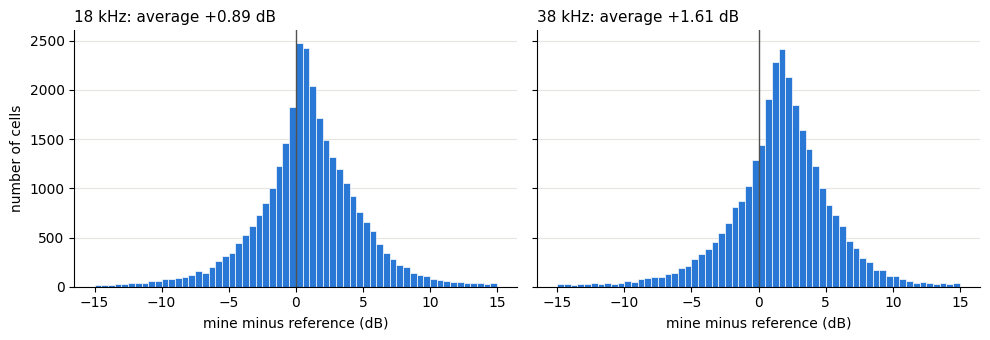

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, column, title in [(axes[0], "diff_18", "18 kHz"), (axes[1], "diff_38", "38 kHz")]:
    ax.hist(cells[column], bins=60, range=(-15, 15), color="#2a78d6", edgecolor="#fcfcfb", linewidth=0.5)
    ax.axvline(0, color="#52514e", linewidth=1)
    ax.set_title(f"{title}: average {cells[column].mean():+.2f} dB", loc="left", fontsize=11)
    ax.set_xlabel("mine minus reference (dB)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
    ax.set_axisbelow(True)
axes[0].set_ylabel("number of cells")
fig.tight_layout()
plt.show()

## 6. The codes themselves

Rows are the reference codes and columns are mine. Each number is a count of cells.

Read this with care. The two sets of codes do not share a meaning: the reference
codes come from a fixed rule, and mine are cluster numbers that change from run
to run. So do not expect code 1 to line up with code 1. What to look for is
whether each reference code lands mostly in **one** of my columns. If it does,
the two analyses are separating the water the same way under different names.

In [ ]:
pd.crosstab(cells["code_ref"], cells["code_mine"], rownames=["reference code"], colnames=["my code"])

my code,-1,0,1,2,3,4
reference code,,,,,,
1,95,1395,335,2363,6278,132
2,118,1112,1602,1316,7630,833
3,56,787,2760,317,1570,1419


In [ ]:
# The reference script adds depth with
#     Sv = ep.consolidate.add_depth(Sv, depth_offset=Sv.water_level.values)
# and the offset silently comes out as zero. This cell shows why on a made-up
# dataset, so it needs no raw file.

import echopype as ep
import numpy as np
import xarray as xr

# A minimal Sv-like dataset: one channel, two pings, five samples.
# echo_range is the distance from the transducer, 0 to 4 m.
# water_level is the transducer depth, stored as a single number like in real data.
toy = xr.Dataset(
    {
        "echo_range": (("channel", "ping_time", "range_sample"), np.tile(np.arange(5.0), (1, 2, 1))),
        "water_level": ((), 6.0),
    },
    coords={
        "channel": ["ch1"],
        "ping_time": np.array(["2016-07-03T18:40:00", "2016-07-03T18:40:02"], dtype="datetime64[ns]"),
        "range_sample": np.arange(5),
    },
)

# Two ways of handing the same 6.0 to add_depth.
# The first is what the script does: .values gives a numpy array holding one number.
# The second wraps it in float(), so it is a plain Python number.
attempts = {
    "Sv.water_level.values   (the script)": toy.water_level.values,
    "float(Sv.water_level.values)   (the fix)": float(toy.water_level.values),
}

for label, offset in attempts.items():
    # add_depth writes depth = depth_offset + echo_range.
    # It only accepts the offset as a plain number or a one-dimensional DataArray;
    # anything else is ignored without a warning and the offset stays at zero.
    result = ep.consolidate.add_depth(toy.copy(deep=True), depth_offset=offset)

    # Subtracting echo_range from depth recovers the offset add_depth actually used.
    applied = float((result["depth"] - result["echo_range"]).max())

    print(label)
    print(f"    passed in : {offset!r}  ({type(offset).__name__})")
    print(f"    offset used by add_depth : {applied} m")
    print()